In [28]:
'''
active_supContrast.py
基于上面py代码，获得labeled data和model weight
然后对unlabeled data进行预测，获得latent
将latent对应的cluster画到sensor data上，并和true label比较
'''

import torch.nn as nn
import torch.nn.functional as F
from sklearn.model_selection import train_test_split
import random
import torch
import pickle
from torch import optim
from torch.utils.data import DataLoader
from umap import UMAP
import plotly.express as px


from sklearn.metrics import adjusted_rand_score, normalized_mutual_info_score, fowlkes_mallows_score, silhouette_score

import matplotlib.patches as patches

import numpy as np
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score, f1_score

# 
from deepview.calculate_results.models.utils import (
    majority_value,
    data_loader_umineko,
)
from deepview.calculate_results.data.umineko.model_func import (
    Autoencoder3d4,  # debug purpose
    Autoencoder1d,
)

from scipy.stats import entropy
from sklearn.semi_supervised import LabelSpreading


def set_random_seed(seed):
    # Set seed for Python's random module
    random.seed(seed)

    # Set seed for NumPy
    np.random.seed(seed)

    # Set seed for PyTorch
    torch.manual_seed(seed)

    # If using CUDA, set seed for GPU as well
    if torch.cuda.is_available():
        torch.cuda.manual_seed(seed)
        torch.cuda.manual_seed_all(seed)  # For multi-GPU setups

OMP_NUM_THREADS=3

# Set a fixed random seed
seed_value = 2025
set_random_seed(seed_value)

labeldict_findstr = {
    -2: 'unknown',
                    -1: 'unknown',
                     0: 'ground_stationary',
                     1: 'stationary',
                     2: 'bathing',
                     3: 'flying_active',
                     4: 'flying_passive',
                     # 5: 'foraging'
                     }
labeldict_wounknown_findstr = {
                     0: 'ground_stationary',
                     1: 'stationary',
                     2: 'bathing',
                     3: 'flying_active',
                     4: 'flying_passive',
                     # 5: 'foraging'
}

label_colors = {
    0: "#5470C6",  # 深蓝 - Attack
    1: "#91CC75",  # 绿色 - Investigation
    2: "#FAC858",  # 金黄 - Mount
    3: "#EE6666",  # 红色 - Category 3
    4: "#73C0DE",  # 天蓝 - Category 4
    5: 'brown',     # 棕色
    6: 'pink',      # 粉色
    7: 'cyan',      # 青色
    8: 'magenta',   # 品红
    9: 'lime',      # 青柠色
    10: 'teal',     # 蓝绿色
    11: 'violet',   # 紫罗兰色
    12: 'gold',     # 金色
    13: 'coral',    # 珊瑚色
    14: 'salmon'    # 三文鱼色
}

act_color_dict = {
        'ground_stationary': "#5470C6",
        # 'ground_stationary': 'red',
        'stationary': "#91CC75",
        # 'stationary': 'blue',
        'bathing': "#FAC858",
        # 'bathing': 'green',
        'flying_active': "#EE6666",
        # 'flying_active': 'orange',
        'flying_passive': "#73C0DE",
        # 'flying_passive': 'purple',
        # 'foraging': 'brown',
    }

def gaussian_std(X):
    mean_val = np.mean(X.astype(float), axis=0)
    std_val = np.std(X.astype(float), axis=0)
    X_standardized = (X - mean_val) / np.maximum(std_val, 10 ** -5)
    return X_standardized


def kmeans_best_numCenters_elbow(X, init_num_centers=2, max_num_centers=10):
    # 计算不同聚类数下的 SSE
    sse = []
    k_values = range(init_num_centers, max_num_centers)
    for k in k_values:
        kmeans = KMeans(n_clusters=k, n_init=10, random_state=42)
        kmeans.fit(X)
        sse.append(kmeans.inertia_)

    # 返回最佳聚类数
    # 计算每两个点之间的差值
    diff = np.diff(sse)
    # 计算每两个差值之间的差值
    second_diff = np.diff(diff)
    # 找到第二个差值的最小值的位置
    elbow_point = np.argmin(second_diff) + 1  # 加1是因为我们计算了第二个差值
    print(f"Elbow point: {elbow_point + init_num_centers}")

    # 绘制肘部法则图
    plt.figure(figsize=(8, 6))
    plt.plot(k_values, sse, marker='o')
    plt.xlabel('Number of clusters (k)')
    plt.ylabel('SSE')
    plt.title('Elbow Method for Optimal k')
    plt.xticks(k_values)
    plt.grid()
    plt.show()
    return elbow_point + init_num_centers


def kmeans_best_numCenters_silhoutte(X, iteration, init_num_centers=2, max_num_centers=10):
    silhouette_scores = []
    k_values = range(init_num_centers, max_num_centers)
    for k in k_values:
        kmeans = KMeans(n_clusters=k, n_init=10, random_state=42)
        labels = kmeans.fit_predict(X)
        silhouette_scores.append(silhouette_score(X, labels))

    # 找到最佳聚类数
    optimal_k = k_values[np.argmax(silhouette_scores)]
    print(f"The optimal number of clusters is: {optimal_k}")

    return optimal_k

def plot_func(representation_list, label_list, count, name):
    label_concat = np.concatenate(label_list)
    if label_concat.ndim == 1:
        label_concat_vote = label_concat
    else:
        label_concat_vote = majority_value(label_concat)
    
    if isinstance(representation_list, list):
        repre_concat = np.concatenate(representation_list)
        repre_reshape = repre_concat.reshape(repre_concat.shape[0], -1).astype(float)
    
        umap_3d = UMAP(n_components=2)
        proj_3d_gyro = umap_3d.fit_transform(repre_reshape)
    else:
        proj_3d_gyro = representation_list

    label_concat_vote_str = [labeldict_findstr[i] for i in label_concat_vote]

    if (count == 1) or (count == 10) or (count == 20) or (count == -1):
        fig_3d = px.scatter(
            proj_3d_gyro, x=0, y=1,
            color=label_concat_vote_str,
            # color=label_concat_vote_str,
            labels={'activity': 'activity'},
            color_discrete_map={'ground_stationary': 'red',
                                'stationary': 'blue',
                                'bathing': 'green',
                                'flying_active': 'orange',
                                'flying_passive': 'purple',
                                'foraging': 'brown',
                                'unknown': 'lightgrey'
                                }
        )
        # Reduce marker size for all points
        for trace in fig_3d.data:
            trace.marker.size = 6  # Adjust the size to your preference (e.g., 6)

        # Update transparency for traces where activity is '-2.0'
        fig_3d.for_each_trace(lambda trace: trace.update(marker=dict(opacity=0.5)) if trace.name == '-2.0' else ())
        fig_3d.update_traces(marker=dict(line=dict(width=0)))  # remove boundary of point
        fig_3d.write_html('%s_activeSupBase_epoch_%s.html' % (name, str(count)))

    ############################################
    # plot cluster results
    n_clusters = kmeans_best_numCenters_silhoutte(proj_3d_gyro, iteration=20,
                                                  init_num_centers=6, max_num_centers=12)
    # Create a KMeans instance
    kmeans = KMeans(n_clusters=n_clusters, n_init=10, random_state=42)

    # Fit the model and get cluster labels
    labels = kmeans.fit_predict(proj_3d_gyro)
    cus_color = [label_colors[i] for i in labels]

    if (count == 1) or (count == 10) or (count == 20) or (count == -1):
        fig_3d = px.scatter(
            proj_3d_gyro, x=0, y=1,
            color=cus_color,
            # color=label_concat_vote_str,
            labels={'color': 'cluster'},
            color_discrete_map={'unknown': 'lightgrey'},
        )
        # Reduce marker size for all points
        for trace in fig_3d.data:
            trace.marker.size = 6  # Adjust the size to your preference (e.g., 6)

        # Update transparency for traces where activity is '-2.0'
        fig_3d.for_each_trace(lambda trace: trace.update(marker=dict(opacity=0.5)) if trace.name == '-2.0' else ())
        fig_3d.update_traces(marker=dict(line=dict(width=0)))  # remove boundary of point
        fig_3d.write_html('%s_activeSupBase_epoch_%s_cluster.html' % (name, str(count)))

    # ##############################
    # # calculate score
    # # 假设 y_true 是真实标签，labels 是聚类标签
    # y_true = label_concat_vote_str  # 真实标签
    # labels = labels  # 聚类标签
    # 
    # # 计算调整兰德指数
    # ari = adjusted_rand_score(y_true, labels)
    # print(f"Adjusted Rand Index: {ari:.4f}")
    # 
    # # 计算归一化互信息
    # nmi = normalized_mutual_info_score(y_true, labels)
    # print(f"Normalized Mutual Information: {nmi:.4f}")
    # 
    # # 计算Fowlkes-Mallows指数
    # fmi = fowlkes_mallows_score(y_true, labels)
    # print(f"Fowlkes-Mallows Index: {fmi:.4f}")
    # 
    # silhouette = silhouette_score(proj_3d_gyro, labels)
    # print(f"Silhouette Score: {silhouette:.4f}")
    return 0, 0, 0, 0, labels, proj_3d_gyro
    # return ari, nmi, fmi, silhouette, labels, proj_3d_gyro


# ======= 2. 数据读取 ======= #

# with open('all_norm_data.pkl', 'wb') as file:  # 'wb'表示以二进制写入模式打开文件
#     pickle.dump({'data': data_b, 'label': label_b}, file)
with open('all_norm_data.pkl', 'rb') as file:  # 'rb'表示以二进制读取模式打开文件
    d_dict = pickle.load(file)
    data_b = d_dict['data']
    label_b = d_dict['label']
    vote_label = majority_value(label_b)
    vote_label[vote_label == 5] = -2  # remove foraging


len_sw = 50
device = 'cpu'
# device = 'cuda:1' if torch.cuda.is_available() else 'cpu'
batch_size = 4000
all_dataset = data_loader_umineko(data_b.astype(float), vote_label)
all_loader = DataLoader(all_dataset, batch_size=batch_size, shuffle=False, drop_last=False)

# 去掉labels为-2的数据
data_select = data_b[vote_label != -2]
label_select = vote_label[vote_label != -2]

# 将数据分为8:2，其中2为测试集
vote_label = majority_value(label_b)
X_train_full, X_test, y_train_full, y_test = train_test_split(data_select,
                                                              label_select,
                                                              test_size=0.2,
                                                              stratify=label_select,
                                                              random_state=42)

# 从X_train_full中随机选择1%的数据作为X_labeled，其余为X_unlabeled
X_labeled, X_unlabeled, y_labeled, y_unlabeled = train_test_split(X_train_full, y_train_full, test_size=0.99, random_state=42)

# 确保X_labeled和X_unlabeled的大小
print("X_labeled shape:", X_labeled.shape)
print("X_unlabeled shape:", X_unlabeled.shape)
print("X_test shape:", X_test.shape)


# ======= 2. 模型与 Supervised Contrastive Learning ======= #
class SimpleNN(nn.Module):
    def __init__(self, input_dim=128 * 6, embedding_dim=128, number_classes=5):
        super(SimpleNN, self).__init__()
        self.acc_encoder = Autoencoder3d4().feature_extractor
        self.pre_encoder = Autoencoder1d().feature_extractor

        self.linear = nn.Linear(input_dim*2, 32)
        self.projector = nn.Sequential(
            nn.Linear(32, 32),
            nn.ReLU(),
            nn.Linear(32, 16)
        )

        self.classifier = nn.Sequential(
            nn.Linear(32, 32),
            nn.ReLU(),
            nn.Linear(32, number_classes),
            nn.Softmax(dim=1),
        )


    def forward(self, data, if_contrast=True):
        accel = data[:, :3, :]
        press = data[:, -1:, :]
        acc_fea, _, _ = self.acc_encoder(accel)
        pre_fea, _, _ = self.pre_encoder(press)
        concat_fea = torch.concat([acc_fea, pre_fea], dim=1)
        concat_fea = self.linear(concat_fea)
        # concat_fea = self.linear(acc_fea)
        if if_contrast:
            output = self.projector(concat_fea)  # output(batch, 128)
        else:
            output = self.classifier(concat_fea)
        return output, concat_fea


class SupContrastiveLoss(nn.Module):
    def __init__(self, temperature=0.3):
        super(SupContrastiveLoss, self).__init__()
        self.temperature = temperature

    def forward(self, features, labels):
        """
        Args:
            features: Tensor of shape [batch_size, feature_dim], normalized embeddings.
            labels: Tensor of shape [batch_size], ground truth labels for the samples.
        Returns:
            loss: Supervised contrastive loss value.
        """
        features = F.normalize(features, dim=1)
        similarity_matrix = torch.matmul(features, features.T) / self.temperature

        # 数值稳定处理
        similarity_matrix = similarity_matrix - torch.max(similarity_matrix, dim=1, keepdim=True)[0]

        # Positive and negative masks
        labels1 = labels.unsqueeze(1)
        mask = torch.eye(similarity_matrix.size(0), dtype=torch.bool, device=features.device)
        positive_mask = (labels1 == labels1.T) & ~mask

        exp_sim = torch.exp(similarity_matrix)
        numerator = exp_sim * positive_mask
        denominator = exp_sim * ~mask

        numerator_sum = numerator.sum(dim=1) + 1e-8
        denominator_sum = denominator.sum(dim=1) + 1e-8

        valid_mask = numerator_sum > 0  # Skip samples with no positive pairs
        loss = -torch.log(numerator_sum[valid_mask] / denominator_sum[valid_mask])
        loss = loss.mean()

        # # cluster center loss
        # all_loss = combined_loss(latent, labels, loss, lambda_intra=1.0, lambda_inter=10)

        return loss


# ======= 3. 模型训练 ======= #

def train_model(model, loader, criterion, optimizer, epochs=500, device='cpu', if_contrast=True):
    model.train()
    avg_loss = []
    for epoch in range(epochs):
        losses = []
        for batch in loader:
            data, labels = batch
            label_vote = majority_value(labels)
            label_vote = torch.from_numpy(label_vote)

            data = data.to(device=device, dtype=torch.float)
            label_vote = label_vote.to(device=device, dtype=torch.long)
            # outputs: supcontrast output; feature: feature extractor output
            outputs, features = model(data, if_contrast)
            loss = criterion(outputs, label_vote)
            losses.append(loss.item())

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()
        avg_loss.append(np.mean(losses))
        # print(f"Epoch {epoch + 1}, Loss: {avg_loss[-1]}")
    return model, avg_loss

def accuracy_class(predict_labels, true_labels):
    # 1. 获取唯一类别
    unique_classes = np.unique(true_labels)

    # 2. 计算每个类别的准确率
    class_accuracies = {}
    for cls in unique_classes:
        # 筛选出属于当前类别的样本
        class_indices = true_labels == cls
        # 计算预测正确的数量和总数量
        correct_predictions = np.sum(predict_labels[class_indices] == true_labels[class_indices])
        total_samples = np.sum(class_indices)
        # 计算准确率
        accuracy = correct_predictions / total_samples if total_samples > 0 else 0
        class_accuracies[cls] = accuracy

    # 输出每个类别的准确率
    for cls, acc in class_accuracies.items():
        print(f"Class {cls}: Accuracy = {acc:.2f}")


def evaluate_model(model, loader):
    # supervised learning
    model.eval()
    ground_truth, prediction = [], []
    data_list, predlabel_list, truelabel_list = [], [], []  # 保存新标签用于supCon训练
    with (torch.no_grad()):
        for data, labels in loader:
            data = data.to(device=device, dtype=torch.float)
            label_vote = majority_value(labels)
            label_vote = torch.from_numpy(label_vote)
            label_vote = label_vote.to(device=device, dtype=torch.long)
            predicts, features = model(data, if_contrast=False)
            max_values, predictions = torch.max(predicts, dim=1)  # max_values用来挑选threshold
            ground_truth.append(label_vote.detach().cpu().numpy())
            prediction.append(predictions.detach().cpu().numpy())
            data_list.append(data.detach().cpu().numpy())

    # 计算准确率
    accuracy = accuracy_score(np.concatenate(ground_truth, axis=0), np.concatenate(prediction, axis=0))
    # print(f'Accuracy: {accuracy:.2f}, Macro F1 Score: {macro_f1:.2f}, Micro F1 Score: {micro_f1:.2f}')
    # 计算 macro F1 分数
    macro_f1 = f1_score(np.concatenate(ground_truth, axis=0), np.concatenate(prediction, axis=0), average='macro')
    # print(f'Macro F1 Score: {macro_f1:.2f}')
    # 计算 micro F1 分数
    micro_f1 = f1_score(np.concatenate(ground_truth, axis=0), np.concatenate(prediction, axis=0), average='micro')
    # print(f'Micro F1 Score: {micro_f1:.2f}')
    print(f'Accuracy: {accuracy:.2f}, Macro F1 Score: {macro_f1:.2f}, Micro F1 Score: {micro_f1:.2f}')
    return accuracy, macro_f1, micro_f1, prediction, ground_truth


def evaluate_supContrast_model(model, loader, cal_threshold=0.0):
    model.eval()
    correct, total = 0, 0
    threshold_acc, threshold_total = 0, 0
    data_list, predlabel_list, truelabel_list = [], [], []  # 保存新标签用于supCon训练
    with torch.no_grad():
        for data, labels in loader:
            data = data.to(device=device, dtype=torch.float)
            label_vote = majority_value(labels)
            label_vote = torch.from_numpy(label_vote)
            label_vote = label_vote.to(device=device, dtype=torch.long)
            predicts, features = model(data, if_contrast=False)
            max_values, predictions = torch.max(predicts, dim=1)  # max_values用来挑选threshold
            correct += (predictions == label_vote).sum().item()

            ## 计算预测值大于cal_threshold前提下的准确率
            # 将 max_values 小于 cal_threshold 的位置上的 max_indices 赋值为 -1
            predictions[max_values < cal_threshold] = -1
            threshold_acc += (predictions == label_vote).sum().item()
            # # 计算 predictions 中 -1 的个数
            # count_neg_ones = (predictions == -1).sum().item()

            ## 保存新标签和数据
            # 获取 predictions 中 -1 的位置
            pos_positions = torch.nonzero(predictions != -1).squeeze()  # squeeze() 去掉多余的维度
            if len(pos_positions) > 0:
                new_data = data[pos_positions].detach().cpu().numpy()
                data_list.append(new_data)

                new_label = predictions[pos_positions].detach().cpu().numpy()
                # reshaped_array = new_label.reshape(new_label.shape[0], 1)  # 将形状从 (batch,) 转换为 (batch, 1)
                # reshaped_array = np.tile(reshaped_array, (1, labels.shape[1]))  # 复制到 (batch, 50)

                t_label = label_vote[pos_positions].detach().cpu().numpy()
                # reshaped_t = t_label.reshape(t_label.shape[0], 1)  # 将形状从 (batch,) 转换为 (batch, 1)
                # reshaped_t = np.tile(reshaped_t, (1, labels.shape[1]))  # 复制到 (batch, 50)

                predlabel_list.append(new_label)
                truelabel_list.append(t_label)
            else:
                data_list.append(data.detach().cpu().numpy())

                new_label = predictions.detach().cpu().numpy()
                # reshaped_array = new_label.reshape(labels.shape[0], 1)  # 将形状从 (batch,) 转换为 (batch, 1)
                # reshaped_array = np.tile(reshaped_array, (1, labels.shape[1]))
                predlabel_list.append(new_label)

                truelabel_list.append(label_vote.detach().cpu().numpy())

    # 重新组合 data和label
    concat_data = np.concatenate(data_list, axis=0)
    concat_label = np.concatenate(predlabel_list, axis=0)
    true_label = np.concatenate(truelabel_list, axis=0)
    # 计算准确率
    accuracy = accuracy_score(true_label, concat_label)
    # print(f'Accuracy: {accuracy:.2f}, Macro F1 Score: {macro_f1:.2f}, Micro F1 Score: {micro_f1:.2f}')
    # 计算 macro F1 分数
    macro_f1 = f1_score(true_label, concat_label, average='macro')
    # print(f'Macro F1 Score: {macro_f1:.2f}')
    # 计算 micro F1 分数
    micro_f1 = f1_score(true_label, concat_label, average='micro')
    # print(f'Micro F1 Score: {micro_f1:.2f}')
    print(f'Accuracy: {accuracy:.2f}, Macro F1 Score: {macro_f1:.2f}, Micro F1 Score: {micro_f1:.2f}')
    return (accuracy, macro_f1, micro_f1,  # accuracy
            concat_data, concat_label, true_label)  # label


def AE_eval_time_series(train_loader, model, device):
    model.eval()

    representation_list = []
    sample_list, timestamp_list, label_list, pred_list, timestr_list, flag_list = [], [], [], [], [], []
    for i, (sample, label) in enumerate(train_loader):
        sample = sample.to(device=device, non_blocking=True, dtype=torch.float)
        # input of autoencoder will be 3D, the backbone is 1d-cnn
        output, x_encoded = model(sample, if_contrast=False)  # x_encoded.shape=batch512,outchannel128,len13
        tmp_representation = x_encoded.detach().cpu().numpy()
        representation_list.append(tmp_representation)
        sample_list.append(sample.detach().cpu().numpy())
        label_list.append(label.detach().cpu().numpy())
        pred_list.append(output.detach().cpu().numpy())

    return representation_list, sample_list, pred_list, label_list


# ======= 5. 循环主动学习 ======= #
# 初始化模型和优化器
model = SimpleNN()
model = model.to(device)
classify_criterion = nn.CrossEntropyLoss()
supContrast_criterion = SupContrastiveLoss()
optimizer = optim.Adam(filter(lambda p: p.requires_grad, model.parameters()), lr=0.001)

# ---------- 主动学习，sample选择策略 ---------- #

def freeze_encoders(model):
    for param in model.acc_encoder.parameters():
        param.requires_grad = False
    for param in model.pre_encoder.parameters():
        param.requires_grad = False
    for param in model.linear.parameters():
        param.requires_grad = False
    for param in model.projector.parameters():
        param.requires_grad = False
    for param in model.classifier.parameters():
        param.requires_grad = True

def unfreeze_encoders(model):
    for name, module in model.named_modules():
        if "encoder" in name:
            for param in module.parameters():
                param.requires_grad = True
    for param in model.linear.parameters():
        param.requires_grad = True
    for param in model.projector.parameters():
        param.requires_grad = True
    for param in model.classifier.parameters():
        param.requires_grad = False
        
def unfreeze_all(model):
    for name, module in model.named_modules():
        if "encoder" in name:
            for param in module.parameters():
                param.requires_grad = True
    for param in model.linear.parameters():
        param.requires_grad = True
    for param in model.projector.parameters():
        param.requires_grad = True
    for param in model.classifier.parameters():
        param.requires_grad = True
        

# 计算样本不确定性（基于熵）
def uncertainty_sampling(X_labeled, y_labeled, X_unlabeled, y_unlabeled, model, update_size):
    model.eval()
    with torch.no_grad():
        # 计算未标注数据和已标注数据的嵌入
        _, unlabeled_embeddings = model(torch.tensor(X_unlabeled, device=device, dtype=torch.float32),
                                        if_contrast=True)
        probs = model.classifier(unlabeled_embeddings)

        uncertainty = entropy(probs.detach().cpu().numpy().T)  # 计算每个样本的熵

        # 选择贡献度最大的样本
        selected_indices = np.argsort(uncertainty)[-update_size:]
        selected_samples = X_unlabeled[selected_indices]
        selected_labels = y_unlabeled[selected_indices]
        ## 更新标注集和未标注数据池
        X_labeled = np.vstack([X_labeled, selected_samples])
        y_labeled = np.concatenate([y_labeled, selected_labels], axis=0)
        X_unlabeled = np.delete(X_unlabeled, selected_indices, axis=0)
        y_unlabeled = np.delete(y_unlabeled, selected_indices, axis=0)
        print(f"Labeled samples: {len(X_labeled)}")

        return X_labeled, y_labeled, X_unlabeled, y_unlabeled, selected_labels


# ---------- 主动学习，sample选择策略 ---------- #
SupCount = 1  # supcontrastive learning
# warmup = 0  # warmup epoch of supcontrastive learning
warmup = 20  # warmup epoch of supcontrastive learning


name_label = '_entropy_Contrast%s_warm%s'%(str(SupCount), str(warmup))
sensor_type = 'AccelPress'
# 主动学习迭代
update_size = max(int(0.01 * len(X_train_full)), 2)  # 每次选择 1% 的样本
batch_size = 4000
iteration = 1
max_iter = 20  # 使用label data训练到这里时用label propagation画图


train_accuracy_list, train_macro_f1_list, train_micro_f1_list = [], [], []
test_accuracy_list, test_macro_f1_list, test_micro_f1_list = [], [], []
test_pred_label_lists, test_truth_label_lists = [], []
weight_list, loss_list, selected_labels_list = [], [], []
ari_list, nmi_list, fmi_list, silhouette_list = [], [], [], []
while len(X_unlabeled) > 0:
    print(f"==============Iteration {iteration}===============")
    print(f"Already labeled samples: {len(X_labeled)}")
    print(f"Remaining unlabeled samples: {len(X_unlabeled)}")

    # 创建数据加载器
    labeled_dataset = data_loader_umineko(X_labeled.astype(float), y_labeled.astype(int))
    labeled_loader = DataLoader(labeled_dataset, batch_size=batch_size, shuffle=True, drop_last=False)

    ## stage 1: train supCon model (所有数据都来训练)
    unfreeze_encoders(model)
    if iteration < warmup:
        # epoch = 500
        epoch = 10
        model, _ = train_model(model, labeled_loader, supContrast_criterion, optimizer,
                                      epochs=epoch, device=device, if_contrast=True)


    ## stage 2: train supervised model, 获得分类器新参数
    freeze_encoders(model)  # only classifier is trainable
    model, _ = train_model(model, labeled_loader, classify_criterion, optimizer,
                                  epochs=50, device=device, if_contrast=False)
    # freeze_projector(model)  # only projector is NOT trainable
    unfreeze_all(model)  # only projector is NOT trainable
    model, avg_loss = train_model(model, labeled_loader, classify_criterion, optimizer,
                            epochs=50, device=device, if_contrast=False)
    loss_list.append(np.average(avg_loss))  # 记录50次epoch的平均loss

    # ### plot
    # repres_list, sample_list, pred_list, label_list = \
    #     AE_eval_time_series(labeled_loader, model, device)
    # ari, nmi, fmi, silhouette, clusterlabels, proj_3d_gyro = (
    #     plot_func(repres_list, label_list,  # not necessary to plot pred_list
    #           iteration, sensor_type+name_label))


    # ======= 6. 模型测试 ======= #
    print('-------Training----------')
    accuracy, macro_f1, micro_f1, pred_label_list, truth_label_list = evaluate_model(model, labeled_loader)
    train_accuracy_list.append(accuracy)
    train_macro_f1_list.append(macro_f1)
    train_micro_f1_list.append(micro_f1)

    test_dataset = data_loader_umineko(X_test.astype(float), y_test.astype(int))
    test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False, drop_last=False)
    print('-------Test----------')
    (accuracy, macro_f1, micro_f1,
     rest_datan, pred_label_list, truth_label_list) = (
        evaluate_supContrast_model(model, test_loader, cal_threshold=0.5))
    test_accuracy_list.append(accuracy)
    test_micro_f1_list.append(micro_f1)
    test_macro_f1_list.append(macro_f1)
    test_pred_label_lists.append(pred_label_list)
    test_truth_label_lists.append(truth_label_list)

    # # print('-------cluster results----------')
    # ari_list.append(ari)
    # nmi_list.append(nmi)
    # fmi_list.append(fmi)
    # silhouette_list.append(silhouette)

    # 保存当前模型权重到列表
    weight_list.append(model.state_dict())

    # # stage 3: 更新数据集
    select_size = min(update_size, len(X_unlabeled))

    ### uncertainty_sampling
    X_labeled, y_labeled, X_unlabeled, y_unlabeled, selected_labels = (
        uncertainty_sampling(X_labeled, y_labeled,
                             X_unlabeled, y_unlabeled,
                             model, select_size))  # data变化了
    selected_labels_list.append(selected_labels)


    iteration += 1
    if iteration == max_iter+1:
        break # 只保存前20次的结果


print("All unlabeled samples have been labeled!")


X_labeled shape: (59, 4, 50)
X_unlabeled shape: (5885, 4, 50)
X_test shape: (1487, 4, 50)
==============Iteration 1===============
Already labeled samples: 59
Remaining unlabeled samples: 5885
-------Training----------
Accuracy: 0.93, Macro F1 Score: 0.79, Micro F1 Score: 0.93
-------Test----------
Accuracy: 0.79, Macro F1 Score: 0.44, Micro F1 Score: 0.79
Labeled samples: 118
==============Iteration 2===============
Already labeled samples: 118
Remaining unlabeled samples: 5826
-------Training----------
Accuracy: 0.94, Macro F1 Score: 0.76, Micro F1 Score: 0.94
-------Test----------
Accuracy: 0.83, Macro F1 Score: 0.59, Micro F1 Score: 0.83
Labeled samples: 177
==============Iteration 3===============
Already labeled samples: 177
Remaining unlabeled samples: 5767
-------Training----------
Accuracy: 0.98, Macro F1 Score: 0.97, Micro F1 Score: 0.98
-------Test----------
Accuracy: 0.86, Macro F1 Score: 0.71, Micro F1 Score: 0.86
Labeled samples: 236
==============Iteration 4=============

## load model weight

In [31]:
# import os
# root_path = r'D:\code\DeepView\deepview\calculate_results\data\umineko'
# def load_data(file_name):
#     with open(os.path.join(root_path, file_name), 'rb') as f:
#         data = pickle.load(f)
#     return data

In [32]:
# file_name = 'AccelTemp__entropy_Contrast1_warm20_epoch20_results.pkl'  # noSupCont, only entropy active learning
# result_dict = load_data(file_name)
# entropy_weight_list = result_dict['weight_list']
# # 假设 model 和 model2 是相同结构的模型
# weight = entropy_weight_list[-1]     # 从 model 提取权重
# model.load_state_dict(weight)   # 加载到 model2


D:\Users\dell\anaconda3\envs\deepviewbackup\lib\site-packages\torch\storage.py:414: FutureWarning:

You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.



<All keys matched successfully>

In [29]:
# iteration = 20
startloc, endloc = 134000, 139000

combinedata = np.concatenate([X_labeled, data_b[startloc:endloc]])
combinelabel_true = np.concatenate([y_labeled, vote_label[startloc:endloc]])
# combinedata = data_b[startloc:endloc]
# combinelabel_true = vote_label[startloc:endloc]

truelabeled_dataset = data_loader_umineko(combinedata.astype(float), combinelabel_true.astype(int))
truelabeled_loader = DataLoader(truelabeled_dataset, batch_size=batch_size, shuffle=False, drop_last=False)

repres_list, sample_list, pred_list, combinelabel_list = \
    AE_eval_time_series(truelabeled_loader, model, device)

repre_concat = np.concatenate(repres_list)
repre_reshape = repre_concat.reshape(repre_concat.shape[0], -1).astype(float)
# print(repre_reshape.shape)

umap_3d = UMAP(n_components=2)
proj_3d_gyro = umap_3d.fit_transform(repre_reshape)
    
# ari, nmi, fmi, silhouette, clusterlabels, _ = (
#     plot_func(proj_3d_gyro, combinelabel_list,  # not necessary to plot pred_list
#           -1, sensor_type+name_label+'_truelabeled_iter%s'%str(max_iter)))


# 1. 通过model prediction，给数据加上标签

In [30]:
all_labels = np.concatenate(combinelabel_list)  # 新数据有标记
all_labels.shape

(6239,)

In [31]:
combinepred_list = np.concatenate(pred_list)  # 新数据有标记
combinepred_list.shape

(6239, 5)

In [32]:
predictions = np.argmax(combinepred_list, axis=1)  # max_values用来挑选threshold
# ground_truth.append(label_vote.detach().cpu().numpy())
predictions.shape

(6239,)

# 2. label propagation渲染方法，给数据加上标签
从已知标签点向周围扩散
这个方法需要有个别标签，所以使用：# combineunlabel = np.concatenate([y_labeled, np.full(vote_label[startloc: endloc].shape, -1)])
目前暂不使用此方法 

In [33]:
combineunlabel = np.concatenate([y_labeled, np.full(vote_label[startloc: endloc].shape, -1)])
# combineunlabel = np.full(vote_label[startloc: endloc].shape, -1)

unlabeled_dataset = data_loader_umineko(combinedata.astype(float), combineunlabel.astype(int))
unlabeled_loader = DataLoader(unlabeled_dataset, batch_size=batch_size, shuffle=False, drop_last=False)

repres_list, sample_list, pred_list, unlabel_list = \
    AE_eval_time_series(unlabeled_loader, model, device)
# ari, nmi, fmi, silhouette, clusterlabels, _ = (
#     plot_func(proj_3d_gyro, unlabel_list,  # not necessary to plot pred_list
#           -1, sensor_type+name_label+'_unlabeled_iter%s'%str(max_iter)))


In [34]:

all_labels_before = np.concatenate(unlabel_list)  # 新数据还没有标记

# Scale the data
scaler = StandardScaler()
data_umap = scaler.fit_transform(proj_3d_gyro)

# Apply Label Spreading for semi-supervised label propagation
label_spread_model = LabelSpreading(kernel='knn', n_neighbors=10, alpha=0.2)  # Graph-based propagation
label_spread_model.fit(data_umap, all_labels_before)

# Get the predicted labels for all data
propagated_labels = label_spread_model.transduction_


# # Check how many unknown labels were assigned
# unique_labels, counts = np.unique(propagated_labels, return_counts=True)
# dict(zip(unique_labels, counts))

In [35]:

# Identify valid and unknown labels
valid_groundtruth = all_labels_before != -1
unknown_groundtruth = all_labels_before == -1

# Data for valid labels
valid_label = all_labels_before[valid_groundtruth]
valid_groundtruth_str = [labeldict_findstr[i] for i in valid_label]
valid_data = data_umap[valid_groundtruth]

# Data for unknown labels
unknown_data = data_umap[unknown_groundtruth]

# Create the figure for known labels
fig_3d = px.scatter(
    valid_data, x=0, y=1,
    color=valid_groundtruth_str,
    labels={'activity': 'activity'},
    color_discrete_map=act_color_dict
)

# Add the unknown labels manually
fig_3d.add_scatter(
    x=unknown_data[:, 0],
    y=unknown_data[:, 1],
    mode='markers',
    marker=dict(size=6, opacity=0.2, color='lightgrey', line=dict(width=0)),
    name='unknown'
)

# Reduce marker size for all valid points and set opacity
fig_3d.update_traces(marker=dict(size=6, opacity=0.5, line=dict(width=0)), selector=dict(name=''))

# Set background to transparent
fig_3d.update_layout(
    paper_bgcolor='rgba(0,0,0,0)',
    plot_bgcolor='rgba(0,0,0,0)',
    legend=dict(font=dict(color='black')),
    xaxis=dict(title="UMAP 0", title_font=dict(color='black'), tickfont=dict(color='black')),
    yaxis=dict(title="UMAP 1", title_font=dict(color='black'), tickfont=dict(color='black')),
    title=dict(font=dict(color='black'))
)

# Save the figure
fig_3d.write_html('label_propagation_before_iter%s_warmup%s.html' % (str(max_iter), str(warmup)))


In [36]:
propagated_labels_str = [labeldict_findstr[i] for i in propagated_labels]
fig_3d = px.scatter(
        data_umap, x=0, y=1,
        color=propagated_labels_str,
        labels={'activity': 'activity'},
        color_discrete_map=act_color_dict
    )

# Reduce marker size for all points and set opacity to 0.6
fig_3d.update_traces(marker=dict(size=6, opacity=0.5, line=dict(width=0)))  # Adjust size, opacity, and remove borders

# Remove boundary of points
fig_3d.update_traces(marker=dict(line=dict(width=0)))

# Set background to transparent
fig_3d.update_layout(
    paper_bgcolor='rgba(0,0,0,0)',  # Transparent background for the whole figure
    plot_bgcolor='rgba(0,0,0,0)',    # Transparent background for the plot area
    legend=dict(font=dict(color='black')),  # Set legend text color to black
    xaxis=dict(title="UMAP 0", title_font=dict(color='black'), tickfont=dict(color='black')),  # X-axis title and tick labels in black
    yaxis=dict(title="UMAP 1", title_font=dict(color='black'), tickfont=dict(color='black')),  # Y-axis title and tick labels in black
    title=dict(font=dict(color='black'))  # Title in black
)

fig_3d.update_traces(marker=dict(line=dict(width=0)))  # remove boundary of point
fig_3d.write_html('label_propagation_predlabel_iter%s_warmup%s.html' % (str(max_iter), str(warmup)))

In [37]:
all_labels = np.concatenate(combinelabel_list)  # 新数据有标记
groundtruth_str = [labeldict_findstr[i] for i in all_labels]

fig_3d = px.scatter(
        data_umap, x=0, y=1,
        color=groundtruth_str,
        labels={'activity': 'activity'},
        color_discrete_map=act_color_dict
    )

# Reduce marker size for all points and set opacity to 0.6
fig_3d.update_traces(marker=dict(size=6, opacity=0.5, line=dict(width=0)))  # Adjust size, opacity, and remove borders

# Remove boundary of points
fig_3d.update_traces(marker=dict(line=dict(width=0)))

# Adjust transparency for 'unknown' labels
for trace, label in zip(fig_3d.data, fig_3d.data[0].legendgroup):
    if label == 'unknown':
        trace.marker.opacity = 0.1  # Set transparency to 0.1
        
# Set background to transparent
fig_3d.update_layout(
    paper_bgcolor='rgba(0,0,0,0)',  # Transparent background for the whole figure
    plot_bgcolor='rgba(0,0,0,0)',    # Transparent background for the plot area
    legend=dict(font=dict(color='black')),  # Set legend text color to black
    xaxis=dict(title="UMAP 0", title_font=dict(color='black'), tickfont=dict(color='black')),  # X-axis title and tick labels in black
    yaxis=dict(title="UMAP 1", title_font=dict(color='black'), tickfont=dict(color='black')),  # Y-axis title and tick labels in black
    title=dict(font=dict(color='black'))  # Title in black
)

fig_3d.update_traces(marker=dict(line=dict(width=0)))  # remove boundary of point
fig_3d.write_html('true_label_all_iter%s_warmup%s.html' % (str(max_iter), str(warmup)))

## 画label标签图
将label在时序列上的分布画出来

In [38]:
startloc, endloc = 134000, 139000
new_data_len = len(data_b[startloc:endloc])
true_newlabel = np.concatenate(combinelabel_list)[-new_data_len:]  
prop_newlabel = propagated_labels[-new_data_len:]
pred_newlabel = predictions

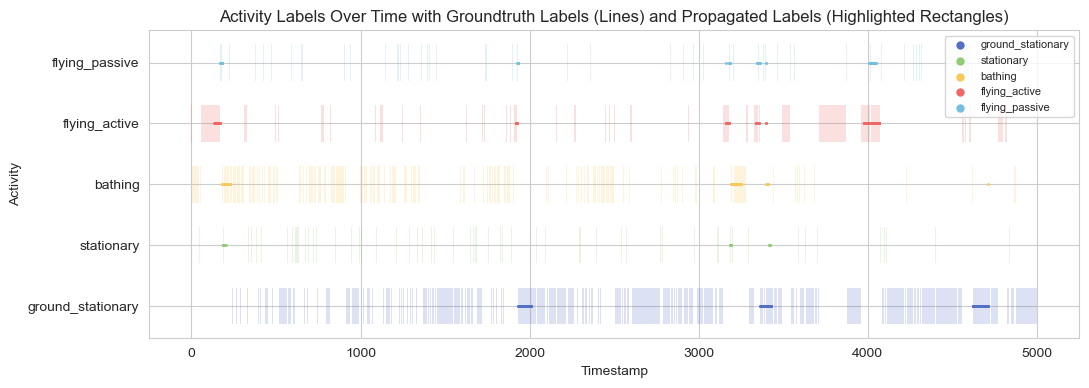

In [39]:

# Create a scatter plot
fig, ax = plt.subplots(figsize=(12, 4))

for label, label_name in labeldict_findstr.items():
    if label >= 0:
        indices = np.where(true_newlabel == label)[0]
        ax.scatter(indices, [label] * len(indices), s=1, color=label_colors[label], label=label_name)

# Add transparent rectangles based on the second vector
window_size = 1  # Define the size of each segment to highlight
for start in range(0, new_data_len, window_size):
    end = start + window_size
    unique_labels = np.unique(prop_newlabel[start:end])
    for label in unique_labels:
        if (label >= 0) and (label in label_colors):
            rect = patches.Rectangle((start, label - 0.3), window_size, 0.6, 
                                     linewidth=0, edgecolor=None, facecolor=label_colors[label], alpha=0.2)
            ax.add_patch(rect)

# Formatting the plot
ax.set_xlabel("Timestamp")
ax.set_ylabel("Activity")
ax.set_title("Activity Labels Over Time with Groundtruth Labels (Lines) and Propagated Labels (Highlighted Rectangles)")
ax.set_yticks(list(labeldict_wounknown_findstr.keys()))
ax.set_yticklabels(list(labeldict_wounknown_findstr.values()))
ax.legend(markerscale=5, fontsize=8, loc='upper right')
plt.savefig(f'propagationlabel_{max_iter}_warmup{warmup}).pdf', bbox_inches='tight')
plt.show()

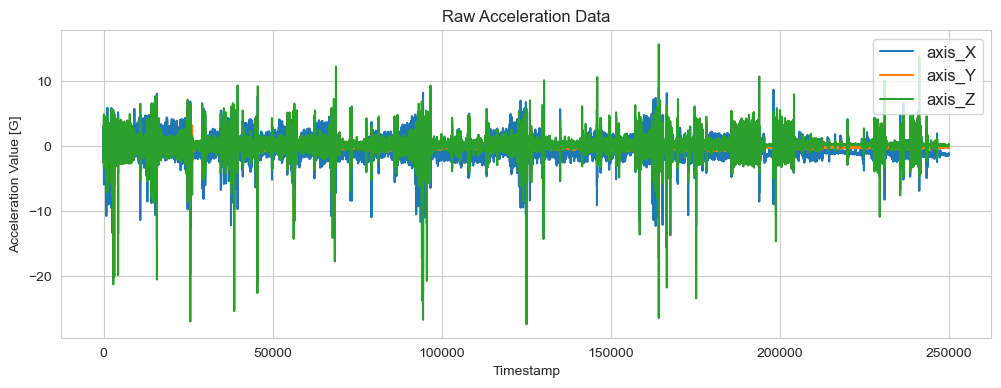

In [13]:
plt.figure(figsize=(12, 4))

acc_data = np.concatenate(data_b[startloc:endloc,:3,:].transpose(0,2,1), axis=0)
plt.plot(acc_data[:,0], label='axis_X')
plt.plot(acc_data[:,1], label='axis_Y')
plt.plot(acc_data[:,2], label='axis_Z')

plt.xlabel("Timestamp")
plt.ylabel("Acceleration Value [G]")
plt.title("Raw Acceleration Data")
# ax.set_yticks(list(labeldict_wounknown_findstr.keys()))
# ax.set_yticklabels(list(labeldict_wounknown_findstr.values()))
plt.legend(markerscale=5, fontsize=12, loc='upper right')
plt.savefig(f'propagation_accel_{max_iter}.pdf', bbox_inches='tight')
plt.show()


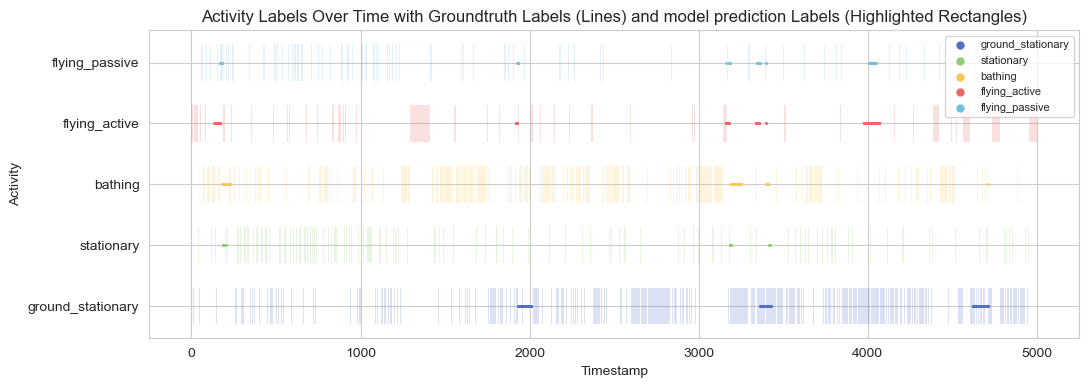

In [40]:
# model prediction label

fig, ax = plt.subplots(figsize=(12, 4))

for label, label_name in labeldict_findstr.items():
    if label >= 0:
        indices = np.where(true_newlabel == label)[0]
        ax.scatter(indices, [label] * len(indices), s=1, color=label_colors[label], label=label_name)

# Add transparent rectangles based on the second vector
window_size = 1  # Define the size of each segment to highlight
for start in range(0, new_data_len, window_size):
    end = start + window_size
    unique_labels = np.unique(pred_newlabel[start:end])
    for label in unique_labels:
        if (label >= 0) and (label in label_colors):
            rect = patches.Rectangle((start, label - 0.3), window_size, 0.6, 
                                     linewidth=0, edgecolor=None, facecolor=label_colors[label], alpha=0.2)
            ax.add_patch(rect)

# Formatting the plot
ax.set_xlabel("Timestamp")
ax.set_ylabel("Activity")
ax.set_title("Activity Labels Over Time with Groundtruth Labels (Lines) and model prediction Labels (Highlighted Rectangles)")
ax.set_yticks(list(labeldict_wounknown_findstr.keys()))
ax.set_yticklabels(list(labeldict_wounknown_findstr.values()))
ax.legend(markerscale=5, fontsize=8, loc='upper right')

plt.savefig(f'modelpred_accel_{max_iter}_warmup{warmup}.pdf', bbox_inches='tight')
plt.show()

# 最后计算label propagatioin和groundtruth label的F1 score